# Лабораторная работа №2: Обнаружение аномалий и выбросов

**Цель работы:** Освоить методы поиска аномалий в данных (outlier detection) с использованием статистических подходов и методов машинного обучения.

**Датасет:** [Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) (данные о прокате велосипедов).
**Основные признаки:**
*   `cnt`: Общее количество прокатов (целевая переменная).
*   `temp`: Нормированная температура.
*   `windspeed`: Скорость ветра.
*   `hum`: Влажность.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Настройка стиля графиков
sns.set(style="whitegrid")

# Загрузка
df = pd.read_csv('data/day.csv')

# Смотрим на данные
display(df.head())
df.info()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


## 1. Профилирование и первичный визуальный анализ
Проверим типы данных, наличие пропусков и посмотрим на распределения ключевых переменных. Нас интересуют признаки, где интуитивно возможны выбросы (например, экстремальная погода или необычный спрос).

               cnt   windspeed         hum
count   731.000000  731.000000  731.000000
mean   4504.348837    0.190486    0.627894
std    1937.211452    0.077498    0.142429
min      22.000000    0.022392    0.000000
25%    3152.000000    0.134950    0.520000
50%    4548.000000    0.180975    0.626667
75%    5956.000000    0.233214    0.730209
max    8714.000000    0.507463    0.972500


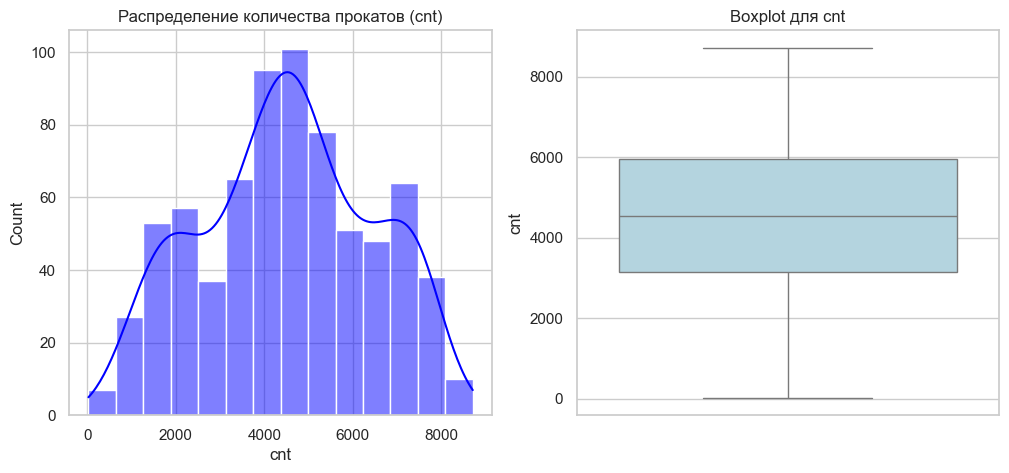

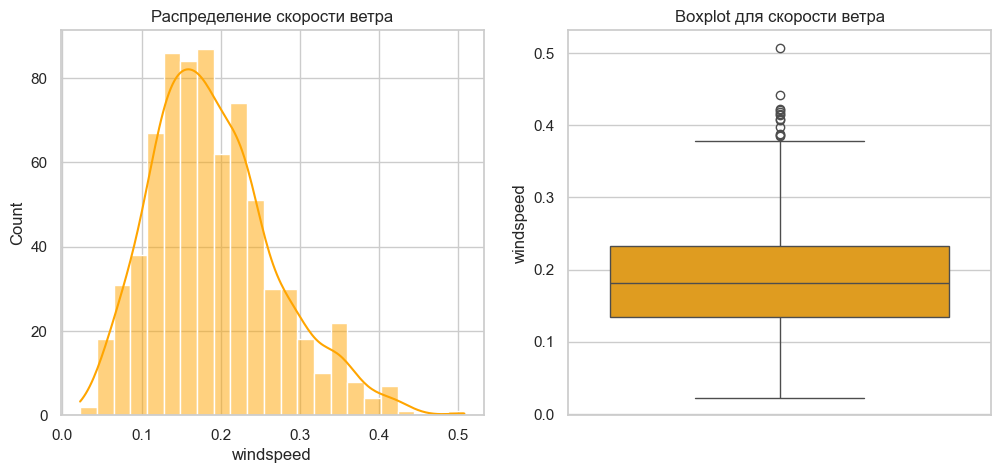

In [3]:
# Описательная статистика
print(df[['cnt', 'windspeed', 'hum']].describe())

# Визуализация распределения целевой переменной
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['cnt'], kde=True, color='blue')
plt.title('Распределение количества прокатов (cnt)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['cnt'], color='lightblue')
plt.title('Boxplot для cnt')
plt.show()

# Визуализация для скорости ветра (тут часто бывают выбросы)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['windspeed'], kde=True, color='orange')
plt.title('Распределение скорости ветра')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['windspeed'], color='orange')
plt.title('Boxplot для скорости ветра')
plt.show()

## 2. Проверка на нормальность распределения
Многие статистические методы (например, правило 3-х сигм) требуют нормального распределения данных.
Проверим переменную `cnt` (спрос) на нормальность с помощью:
1. **QQ-Plot** (График квантиль-квантиль).
2. **Теста Шапиро-Уилка** (Shapiro-Wilk test).

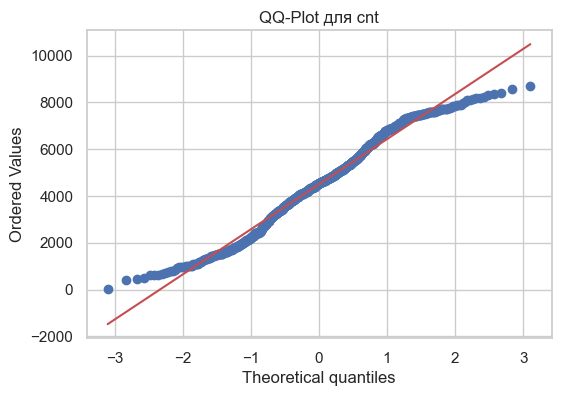

Statistic: 0.9801, p-value: 0.0000000208
Распределение НЕ нормальное (отвергаем H0)


In [4]:
# QQ-Plot
plt.figure(figsize=(6, 4))
stats.probplot(df['cnt'], dist="norm", plot=plt)
plt.title('QQ-Plot для cnt')
plt.show()

# Тест Шапиро-Уилка
stat, p_value = stats.shapiro(df['cnt'])
print(f"Statistic: {stat:.4f}, p-value: {p_value:.10f}")

alpha = 0.05
if p_value > alpha:
    print("Распределение похоже на нормальное (не отвергаем H0)")
else:
    print("Распределение НЕ нормальное (отвергаем H0)")

## 2. Проверка на нормальность распределения
Многие статистические методы (например, правило 3-х сигм) требуют нормального распределения данных.
Проверим переменную `cnt` (спрос) на нормальность с помощью:
1. **QQ-Plot** (График квантиль-квантиль).
2. **Теста Шапиро-Уилка** (Shapiro-Wilk test).

Количество выбросов по Z-score: 2
Количество выбросов по IQR: 13


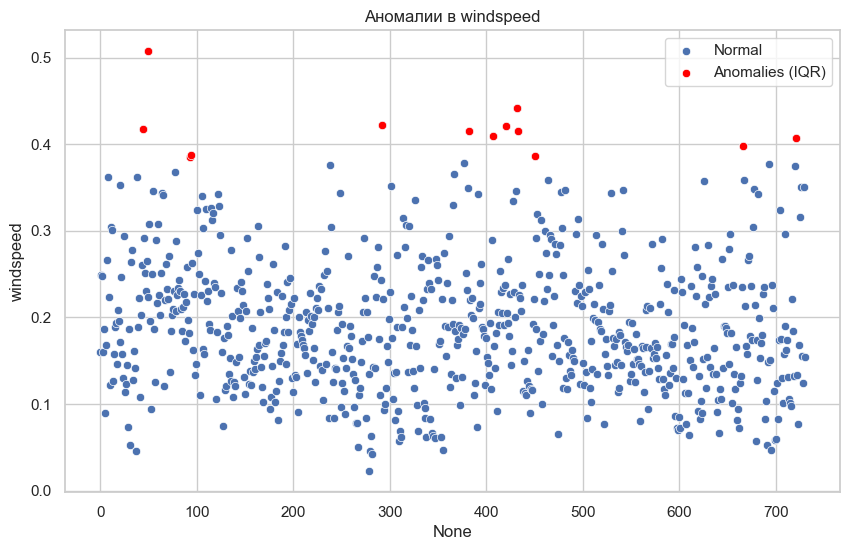

In [5]:
target_col = 'windspeed'

# --- Метод Z-score ---
# Находим Z-оценки
df['z_score_wind'] = (df[target_col] - df[target_col].mean()) / df[target_col].std()

# Флаг выброса: |Z| > 3
outliers_z = df[abs(df['z_score_wind']) > 3]
print(f"Количество выбросов по Z-score: {len(outliers_z)}")

# --- Метод IQR ---
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]
print(f"Количество выбросов по IQR: {len(outliers_iqr)}")

# Визуализация выбросов (на примере IQR)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df.index, y=df[target_col], label='Normal')
sns.scatterplot(x=outliers_iqr.index, y=outliers_iqr[target_col], color='red', label='Anomalies (IQR)')
plt.title(f'Аномалии в {target_col}')
plt.legend()
plt.show()

## 2. Проверка на нормальность распределения
Многие статистические методы (например, правило 3-х сигм) требуют нормального распределения данных.
Проверим переменную `cnt` (спрос) на нормальность с помощью:
1. **QQ-Plot** (График квантиль-квантиль).
2. **Теста Шапиро-Уилка** (Shapiro-Wilk test).

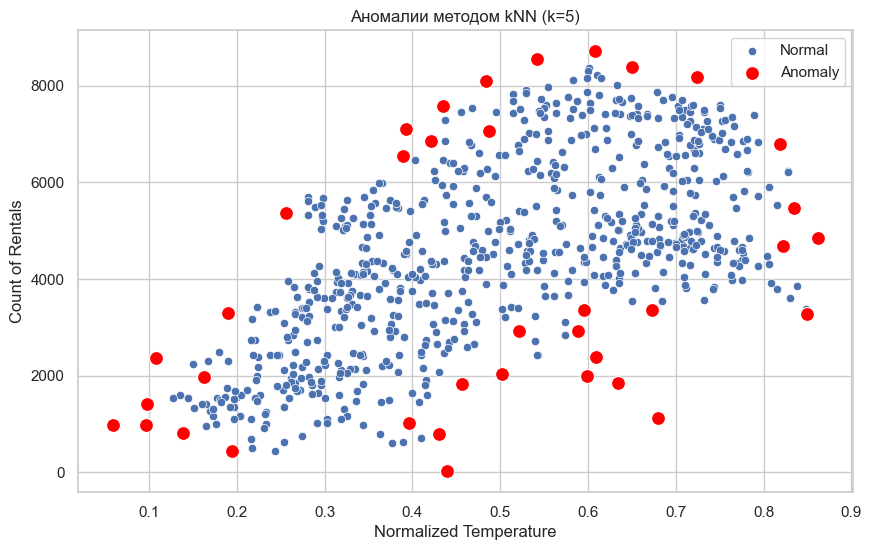

In [6]:
# 1. Выбор признаков
features = ['temp', 'cnt']
X = df[features].copy()

# 2. Масштабирование (обязательно для kNN!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Применение kNN для поиска аномалий
k = 5 # Количество соседей
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# 4. Считаем среднее расстояние до k соседей для каждой точки
mean_distances = distances.mean(axis=1)

# 5. Определяем порог (например, топ 5% самых удаленных точек)
threshold = np.percentile(mean_distances, 95)
df['anomaly_knn'] = mean_distances > threshold

# 6. Визуализация
plt.figure(figsize=(10, 6))
# Нормальные
sns.scatterplot(x=df.loc[~df['anomaly_knn'], 'temp'], 
                y=df.loc[~df['anomaly_knn'], 'cnt'], 
                label='Normal')
# Аномалии
sns.scatterplot(x=df.loc[df['anomaly_knn'], 'temp'], 
                y=df.loc[df['anomaly_knn'], 'cnt'], 
                color='red', s=100, label='Anomaly')

plt.title(f'Аномалии методом kNN (k={k})')
plt.xlabel('Normalized Temperature')
plt.ylabel('Count of Rentals')
plt.legend()
plt.show()

## Выводы

В ходе лабораторной работы были применены различные методы обнаружения аномалий к датасету проката велосипедов:

1.  **Анализ распределения:**
    *   Тест Шапиро-Уилка показал, что распределение целевой переменной `cnt` **не является нормальным** ($p < 0.05$). Это означает, что методы, жестко опирающиеся на нормальность (как правило 3-х сигм), могут давать неточные результаты.

2.  **Статистические методы (Z-score vs IQR) для скорости ветра:**
    *   **Z-score** (параметрический метод) выявил меньше выбросов, указав только на экстремально высокие значения скорости ветра.
    *   **IQR** (робастный метод) оказался более чувствительным и пометил как выбросы более широкий диапазон высоких значений ветра. Для данных с "тяжелыми хвостами" IQR подходит лучше.

3.  **Метод kNN (Локальная плотность):**
    *   Позволил найти аномалии во взаимосвязи двух переменных (`temp` и `cnt`).
    *   На графике видно, что красные точки (аномалии) — это в основном дни, когда **температура была низкой, но спрос неожиданно высоким**, либо когда **температура была комфортной, но спрос аномально низким** (нижняя центральная часть графика). Такие случаи невозможно найти, анализируя переменные по отдельности.